<a href="https://colab.research.google.com/github/guebin/DL2026/blob/master/posts/Prj3.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" style="text-align: left"></a>

13주차 마지막에 다룬 것과 같이, `ddgs` 를 이용하여 웹에서 이미지를 크롤링하고 이를 분류하는 문제이다.

아래의 코드를 실행하면 `taylor`(테일러 스위프트), `ariana`(아리아나 그란데) 두 사람의 이미지가 클래스별로 `./images/` 폴더에 저장된다. 단, **클래스당 수집 장수(`target_per_class`)는 비어 있다(`???`).** 적절한 값을 직접 정해서 채운 뒤 코드를 실행할 것.

In [ ]:
!uv pip install --system -q ddgs

In [3]:
from pathlib import Path
import time
import httpx
from ddgs import DDGS
from PIL import Image
import torch
import torchvision

In [4]:
queries = {
    "taylor": [
        "Taylor Swift portrait",
        "Taylor Swift face",
        "Taylor Swift smile",
        "Taylor Swift Eras tour",
        "Taylor Swift Reputation tour",
        "Taylor Swift 1989 tour",
        "Taylor Swift Grammy",
        "Taylor Swift VMA",
        "Taylor Swift AMA",
        "Taylor Swift Billboard awards",
        "Taylor Swift red carpet",
        "Taylor Swift photoshoot",
        "Taylor Swift magazine cover",
        "Taylor Swift Vogue",
        "Taylor Swift Time magazine",
        "Taylor Swift interview",
        "Taylor Swift live performance",
        "Taylor Swift music video",
        "Taylor Swift NFL",
        "Taylor Swift Blank Space",
        "Taylor Swift Anti-Hero",
        "Taylor Swift Cruel Summer",
        "Taylor Swift Lover",
        "Taylor Swift Midnights",
        "Taylor Swift Folklore",
        "Taylor Swift Bad Blood",
    ],
    "ariana": [
        "Ariana Grande",
        "Ariana Grande portrait",
        "Ariana Grande face",
        "Ariana Grande smile",
        "Ariana Grande Sweetener tour",
        "Ariana Grande Honeymoon tour",
        "Ariana Grande Dangerous Woman tour",
        "Ariana Grande Grammy",
        "Ariana Grande VMA",
        "Ariana Grande AMA",
        "Ariana Grande Billboard awards",
        "Ariana Grande red carpet",
        "Ariana Grande photoshoot",
        "Ariana Grande magazine cover",
        "Ariana Grande Vogue",
        "Ariana Grande Wicked premiere",
        "Ariana Grande interview",
        "Ariana Grande music video",
        "Ariana Grande SNL",
        "Ariana Grande Thank U Next",
        "Ariana Grande 7 Rings",
        "Ariana Grande Side To Side",
        "Ariana Grande Into You",
        "Ariana Grande God Is A Woman",
        "Ariana Grande Positions",
        "Ariana Grande Sweetener",
        "Ariana Grande Problem",
    ],
}
target_per_class = 800  # <-- 클래스당 수집 장수를 직접 정할 것
base_dir = Path.cwd() / "images"

def ddgs_search(q, retries=3):
    """매 호출마다 새 세션 + 재시도."""
    for attempt in range(retries):
        try:
            with DDGS() as ddgs:
                return list(ddgs.images(q, region="us-en", max_results=200))
        except Exception:
            time.sleep(8 + attempt * 5)
    return None


with httpx.Client(timeout=10, follow_redirects=True) as client:
    for kw, qs in queries.items():
        save_dir = base_dir / kw
        save_dir.mkdir(parents=True, exist_ok=True)
        seen, saved = set(), 0
        print(f"\n===== '{kw}' 이미지 다운로드 → {save_dir} =====")

        for q in qs:
            if saved >= target_per_class:
                break
            results = ddgs_search(q)
            if results is None:
                print(f"  '{q}': (요청 실패)")
                continue
            q_saved = 0
            for r in results:
                if saved >= target_per_class:
                    break
                url = r.get("image")
                if not url or url in seen:
                    continue
                seen.add(url)
                try:
                    resp = client.get(url, headers={"User-Agent": "Mozilla/5.0"})
                    resp.raise_for_status()
                    ext = url.split("?")[0].split(".")[-1].lower()
                    if ext not in {"jpg", "jpeg", "png", "gif", "webp"}:
                        ext = "jpg"
                    saved += 1
                    q_saved += 1
                    (save_dir / f"{kw}_{saved:03d}.{ext}").write_bytes(resp.content)
                except Exception:
                    continue
            print(f"  '{q}': +{q_saved}장 (누적 {saved})")
        print(f"{kw}: 총 {saved}장 저장 (dedup 전)")


# ===== 손상 이미지 제거 =====
for p in base_dir.rglob("*"):
    if p.is_file():
        try:
            with Image.open(p) as im:
                im.verify()
        except Exception:
            print(f"remove broken: {p}")
            p.unlink()


===== 'taylor' 이미지 다운로드 → /home/cgb5/Dropbox/02-lec/DL2026/posts/images/taylor =====
  'Taylor Swift portrait': +0장 (누적 0)
  'Taylor Swift face': +1장 (누적 1)
  'Taylor Swift smile': +30장 (누적 31)
  'Taylor Swift Eras tour': +32장 (누적 63)
  'Taylor Swift Reputation tour': +34장 (누적 97)
  'Taylor Swift 1989 tour': +34장 (누적 131)
  'Taylor Swift Grammy': +30장 (누적 161)
  'Taylor Swift VMA': +33장 (누적 194)
  'Taylor Swift AMA': +30장 (누적 224)
  'Taylor Swift Billboard awards': +35장 (누적 259)
  'Taylor Swift red carpet': +32장 (누적 291)
  'Taylor Swift photoshoot': +31장 (누적 322)
  'Taylor Swift magazine cover': +35장 (누적 357)
  'Taylor Swift Vogue': +31장 (누적 388)
  'Taylor Swift Time magazine': +29장 (누적 417)
  'Taylor Swift interview': +33장 (누적 450)
  'Taylor Swift live performance': +1장 (누적 451)
  'Taylor Swift music video': +35장 (누적 486)
  'Taylor Swift NFL': +1장 (누적 487)
  'Taylor Swift Blank Space': +1장 (누적 488)
  'Taylor Swift Anti-Hero': +33장 (누적 521)
  'Taylor Swift Cruel Summer': +31장 (누적 552)

`(1)` 사전학습된 `resnet18` 으로 `taylor` / `ariana` 를 분류하는 네트워크를 학습하라.

> **정답 인정 기준:** `test_acc` 가 **80% 이상**인 경우에만 정답으로 인정한다.

`(2)` 학습한 네트워크 `net` 을 이용하여, 임의의 이미지 URL을 입력하면 그 이미지를 불러와 **그림을 그려주고 예측값(softmax 확률)·예측클래스를 출력**하는 함수를 구현하라. 

*구현예시*

prediction: ariana (ariana 99.9968%, taylor 0.0032%)
logits = [5.833836078643799, -4.523235321044922]


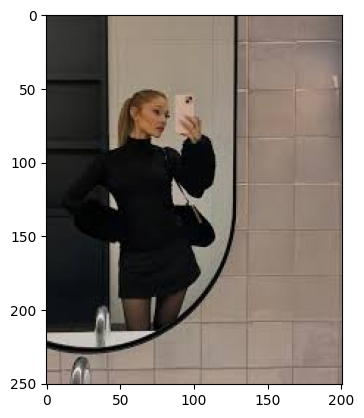

In [15]:
# 임의의 taylor / ariana 이미지 URL 을 넣어 실행
predict("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSQx5yWXLFlpwKZkZT5v9Jps0gS3Y1PAmLYUQ&s")